In [13]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v22.dream_cytof.EGFR_MAPK")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "par_median_frob_norm", "par_dev_frob_norm", "_step"]
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
                # Frobenius norms of medians and deviations
                "par_median_frob_norm": row["par_median_frob_norm"],
                "par_dev_frob_norm": row["par_dev_frob_norm"],
            })

results_df = pd.DataFrame(all_rows)

Exception ignored in: <function tqdm.__del__ at 0x32d7cb5b0>
Traceback (most recent call last):
  File "/Users/fabring/dmm_env_310/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/fabring/dmm_env_310/lib/python3.10/site-packages/tqdm/std.py", line 1267, in close
    if self.disable:
AttributeError: 'tqdm' object has no attribute 'disable'
100%|██████████| 1500/1500 [27:05<00:00,  1.08s/it]


In [14]:
results_df.to_csv("results_16052025_featuressel_nhidden3.csv", index=False)

# Restart from here

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
results_df = pd.read_csv("results_16052025_featuressel_nhidden3.csv")
baseline_df = pd.read_csv("baseline_performance/baseline_regressors_rmse_newcv_newselect.csv")

In [2]:
results_df.sort_values(by=["context", "samples", "job", "step"], inplace=True)
baseline_df.sort_values(by=["context", "features", "features_selection", "dataset"], inplace=True)

<Figure size 1000x600 with 0 Axes>

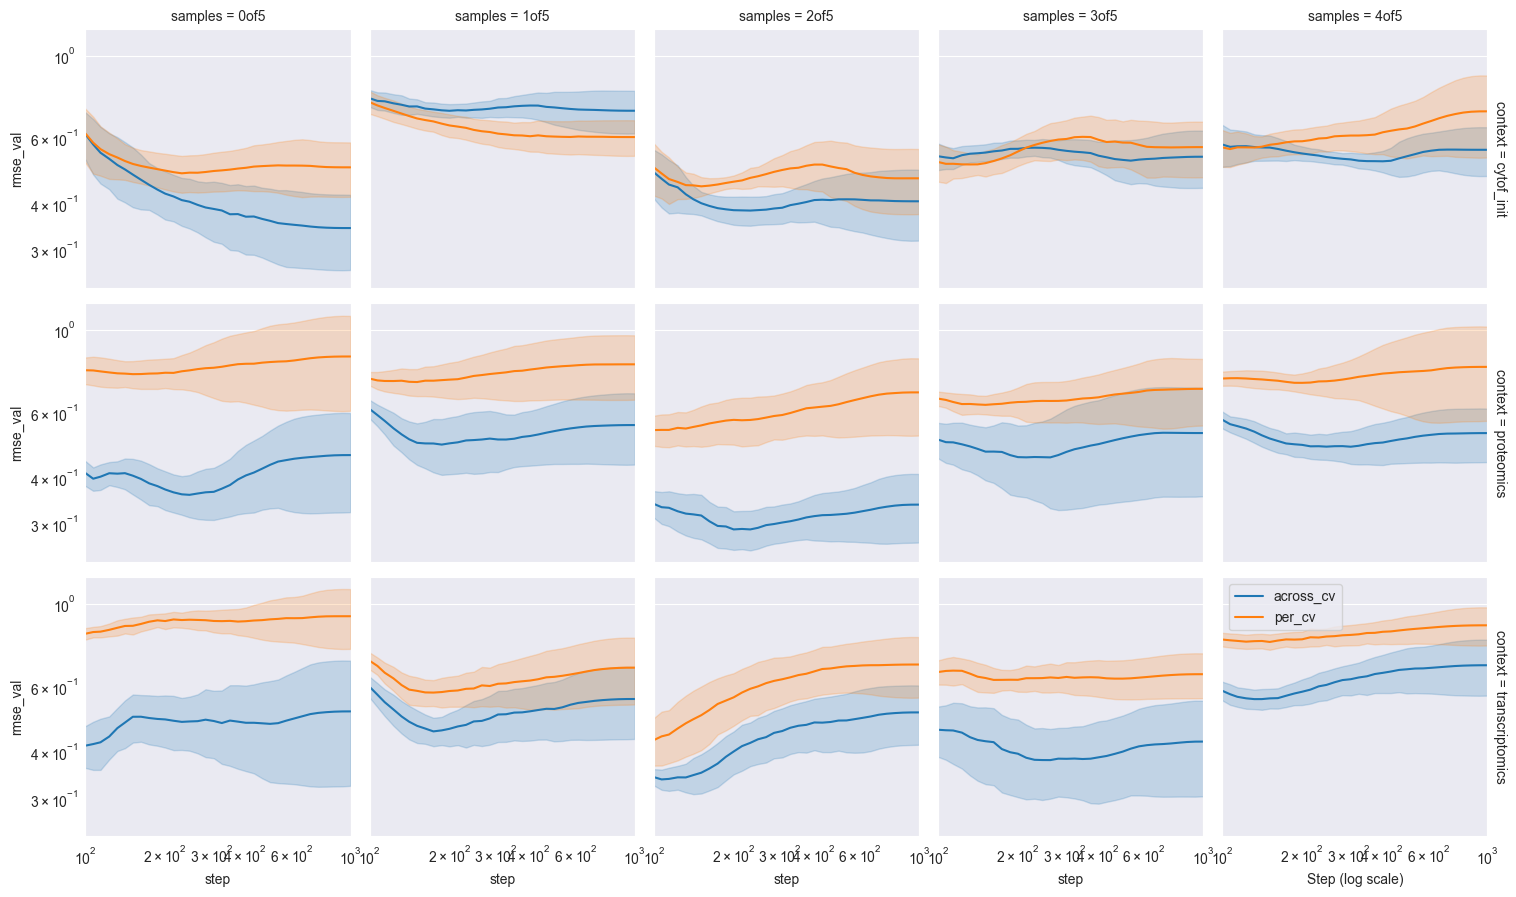

In [3]:
# Plot the results (rmse_val) by context and samples (sparse_threshold_perc by hue)
plt.figure(figsize=(10, 6))
g = sns.FacetGrid(
    results_df,
    row="context",
    row_order=sorted(results_df["context"].unique()),
    col="samples",
    col_order=sorted(results_df["samples"].unique()),
    margin_titles=True,
    despine=False,
    hue="features_selection",
    hue_order=sorted(results_df["features_selection"].unique()),
    palette="tab10",
)
g.map_dataframe(
    sns.lineplot,
    x="step",
    y="rmse_val",
    errorbar="sd",
)
plt.xlim([100, 1000])
plt.xscale("log")
plt.xlabel("Step (log scale)")
plt.ylabel("RMSE (validation)")
plt.yscale("log")
plt.legend()


In [4]:
def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

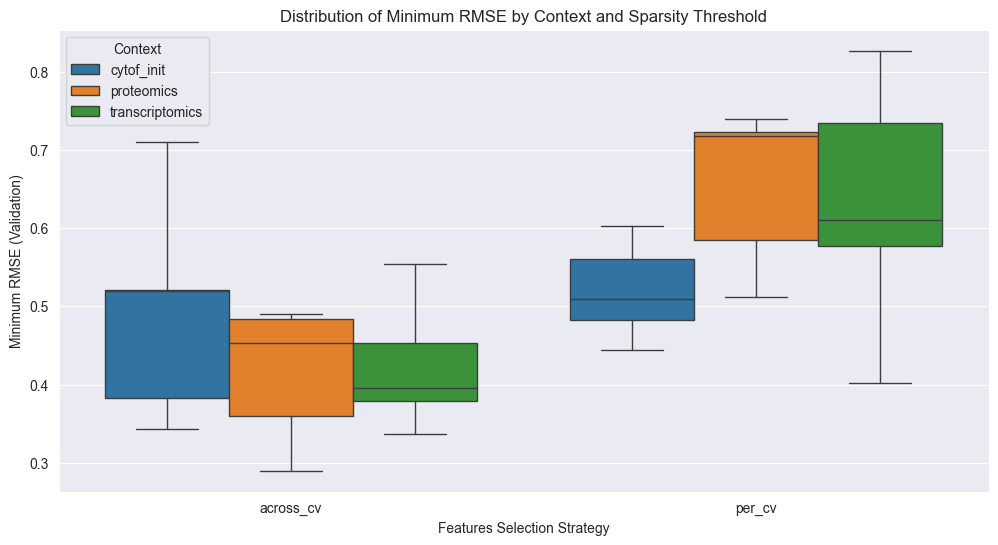

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.10, p-value=0.7540
Context: proteomics - Kruskal-Wallis H-test: H-statistic=6.82, p-value=0.0090
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=4.81, p-value=0.0283


In [5]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Average profiles -- across `job`
mean_rmse_df = results_df.groupby(
    ['context', 'n_hidden', 'samples', 'sparse_threshold_perc', 'features_selection', 'step']
).agg(
    mean_rmse_val=('rmse_val', 'mean')
).reset_index()

# Step 2: Take the minimum of the averaged `mean_rmse_val` -- across `step`
min_mean_rmse_df = mean_rmse_df.groupby(
    ['context', 'n_hidden', 'samples', 'sparse_threshold_perc', 'features_selection']
).agg(
    min_mean_rmse_val=('mean_rmse_val', 'min')
).reset_index()

# Visualize the distribution of min mean rmse_val
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=min_mean_rmse_df,
    x='features_selection',
    y='min_mean_rmse_val',
    hue='context',
    palette='tab10'
)
plt.xlabel('Features Selection Strategy')
plt.ylabel('Minimum RMSE (Validation)')
plt.title('Distribution of Minimum RMSE by Context and Sparsity Threshold')
plt.legend(title='Context')
plt.show()

# Perform statistical significance test (e.g., Kruskal-Wallis test)
kruskal_wallis_groups(min_mean_rmse_df, "min_mean_rmse_val", "features_selection")

In [6]:
min_mean_rmse_df

,context,n_hidden,samples,sparse_threshold_perc,features_selection,min_mean_rmse_val
0,cytof_init,3,0of5,40,across_cv,0.343167
1,cytof_init,3,0of5,40,per_cv,0.481849
2,cytof_init,3,1of5,40,across_cv,0.709932
3,cytof_init,3,1of5,40,per_cv,0.603201
4,cytof_init,3,2of5,40,across_cv,0.382479
5,cytof_init,3,2of5,40,per_cv,0.444467
6,cytof_init,3,3of5,40,across_cv,0.521197
7,cytof_init,3,3of5,40,per_cv,0.509074
8,cytof_init,3,4of5,40,across_cv,0.519109
9,cytof_init,3,4of5,40,per_cv,0.560002


## Compare mean best RMSE with baselines and regressors

In [7]:
best_rmse_df = min_mean_rmse_df.copy()
best_rmse_df.rename(columns={"min_mean_rmse_val": "rmse"}, inplace=True)
best_rmse_df["mode"] = "dmm"

best_df = pd.concat(
    [
        baseline_df[baseline_df.dataset == "val"][["context", "features_selection", "samples", "mode", "rmse"]], best_rmse_df[["context", "samples", "features_selection", "mode", "rmse"]]
    ], ignore_index=True)


<Figure size 1200x600 with 0 Axes>

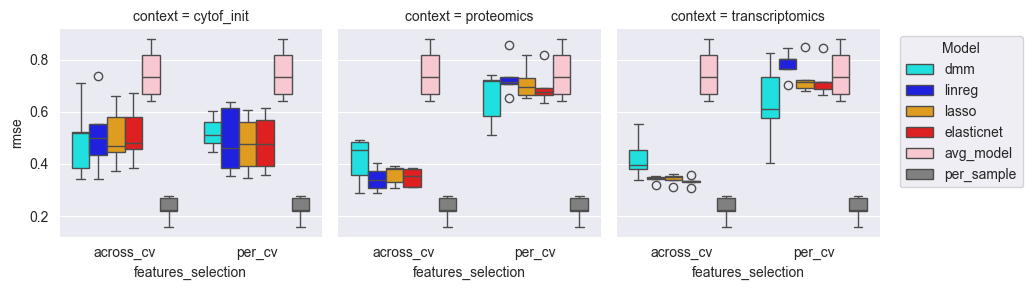

In [8]:
# Visualize the distribution of min mean rmse_val
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(
    best_df,
    col="context",
    col_order=sorted(best_df["context"].unique()),
)
g.map_dataframe(
    sns.boxplot,
    x="features_selection",
    y="rmse",
    hue="mode",
    hue_order=["dmm", "linreg", "lasso", "elasticnet", "avg_model", "per_sample"],
    palette={
        "dmm": "cyan",
        "linreg": "blue",
        "lasso": "orange",
        "elasticnet": "red",
        "avg_model": "pink",
        "per_sample": "gray"
    }
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Model")


## Compare final RMSE with baselines and regressors

In [9]:
final_rmse_df = mean_rmse_df[mean_rmse_df.step == mean_rmse_df.step.max()]
final_rmse_df.rename(columns={"mean_rmse_val": "rmse"}, inplace=True)
final_rmse_df["mode"] = "dmm"

final_df = pd.concat(
    [
        baseline_df[baseline_df.dataset == "val"][["context", "features_selection", "samples", "mode", "rmse"]], final_rmse_df[["context", "samples", "features_selection", "mode", "rmse"]]
    ], ignore_index=True)

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_42672/3865669641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rmse_df.rename(columns={"mean_rmse_val": "rmse"}, inplace=True)
/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_42672/3865669641.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rmse_df["mode"] = "dmm"


<Figure size 1200x600 with 0 Axes>

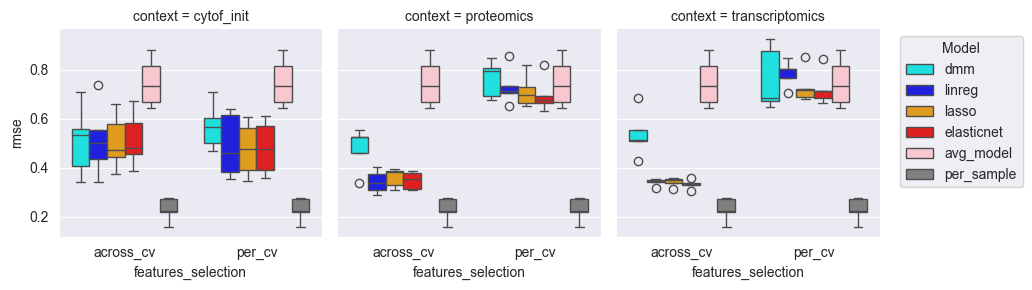

In [10]:
# Visualize the distribution of min mean rmse_val
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(
    final_df,
    col="context",
    col_order=sorted(final_df["context"].unique()),
)
g.map_dataframe(
    sns.boxplot,
    x="features_selection",
    y="rmse",
    hue="mode",
    hue_order=["dmm", "linreg", "lasso", "elasticnet", "avg_model", "per_sample"],
    palette={
        "dmm": "cyan",
        "linreg": "blue",
        "lasso": "orange",
        "elasticnet": "red",
        "avg_model": "pink",
        "per_sample": "gray"
    }
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Model")


## Compare difference between final and best RMSE between features selection strategies

In [11]:
# Compare difference between final rmse_val and best rmse_val
temp = results_df.groupby(
    ["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection", "job"]  # include job
).agg(
    final_rmse_val=("rmse_val", "last"),
    best_rmse_val=("rmse_val", "min"),
).reset_index()
temp["rmse_diff_perc"] = (temp["final_rmse_val"] - temp["best_rmse_val"])/temp["best_rmse_val"] * 100


In [12]:
temp.groupby(["context", "n_hidden", "sparse_threshold_perc", "features_selection"])["rmse_diff_perc"].mean()

context          n_hidden  sparse_threshold_perc  features_selection
cytof_init       3         40                     across_cv             12.539682
                                                  per_cv                19.103073
proteomics       3         40                     across_cv             29.313511
                                                  per_cv                32.288823
transcriptomics  3         40                     across_cv             43.305222
                                                  per_cv                39.473361
Name: rmse_diff_perc, dtype: float64

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=7.69, p-value=0.0056
Context: proteomics - Kruskal-Wallis H-test: H-statistic=1.53, p-value=0.2158
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=1.46, p-value=0.2271


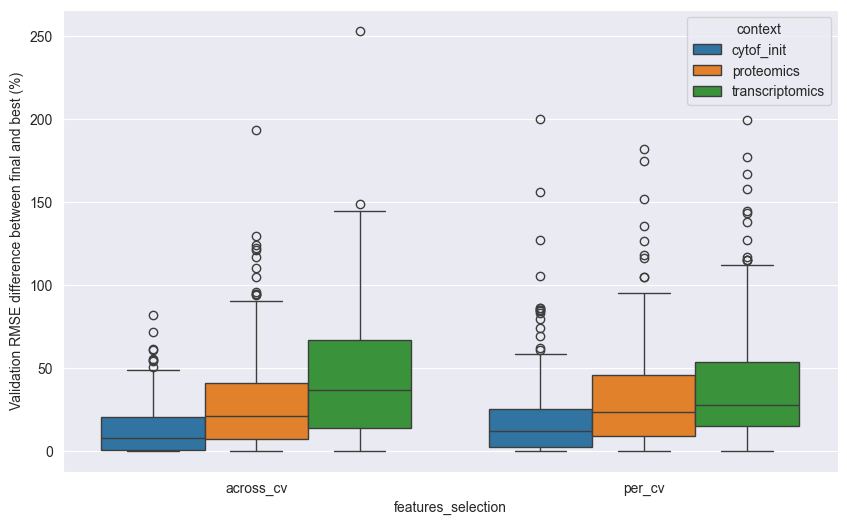

In [13]:
# Plot same results as above in a barplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    temp,
    x="features_selection",
    y="rmse_diff_perc",
    hue="context",
    palette="tab10",
).set_ylabel("Validation RMSE difference between final and best (%)")

# Test for statistical significance in the difference
kruskal_wallis_groups(temp, "rmse_diff_perc", "features_selection")

## Subset to top10 training jobs

In [14]:
# Step 1: Aggregate final rmse_train per job
agg_results = results_df.groupby(
    ["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection", "job"]
).agg(
    final_rmse_train=("rmse_train", "last"),
).reset_index()

# Step 2: For each (context, samples, sparse_threshold_perc), select top 10 jobs
top10_jobs = (
    agg_results
    .sort_values(["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection", "final_rmse_train"])
    .groupby(["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection",])
    .head(10)  # top 10 lowest rmse_train
)

# Step 3: Merge top 10 jobs back to original results
merged_top10 = results_df.merge(
    top10_jobs[["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection", "job"]],
    on=["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection", "job"],
    how="inner"
)

# Step 4: Now compute mean and final rmse_val for these runs
summary_top10 = (
    merged_top10
    .groupby(["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection", "job"])
    .agg(
        min_rmse_val=("rmse_val", "min"),
        final_rmse_val=("rmse_val", "last"),
    )
    .reset_index()
)
summary_top10["rmse_val_diff"] = summary_top10["final_rmse_val"] - summary_top10["min_rmse_val"]

# Optional: If you want an overall summary (across the 10 jobs) per (context, samples, sparse_threshold_perc)
overall_summary = (
    summary_top10
    .groupby(["context", "n_hidden", "samples", "sparse_threshold_perc", "features_selection",])
    .agg(
        mean_of_mins=("min_rmse_val", "mean"),
        mean_of_finals=("final_rmse_val", "mean"),
        mean_of_diffs=("rmse_val_diff", "mean")
    )
    .reset_index()
)

overall_summary.groupby(["context", "n_hidden", "sparse_threshold_perc", "features_selection"])[["mean_of_mins", "mean_of_finals", "mean_of_diffs"]].mean()

mean_of_mins  \
context         n_hidden sparse_threshold_perc features_selection                 
cytof_init      3        40                    across_cv               0.429963   
                                               per_cv                  0.472094   
proteomics      3        40                    across_cv               0.382252   
                                               per_cv                  0.585978   
transcriptomics 3        40                    across_cv               0.373670   
                                               per_cv                  0.570097   

                                                                   mean_of_finals  \
context         n_hidden sparse_threshold_perc features_selection                   
cytof_init      3        40                    across_cv                 0.498154   
                                               per_cv                    0.555951   
proteomics      3        40                    across_cv                 0.524032   
                                               per_cv                    0.771156   
transcriptomics 3        40                    across_cv                 0.514307   
                                               per_cv                    0.733397   

                                                                   mean_of_diffs  
context         n_hidden sparse_threshold_perc features_selection                 
cytof_init      3        40                    across_cv                0.068191  
                                               per_cv                   0.083858  
proteomics      3        40                    across_cv                0.141780  
                                               per_cv                   0.185179  
transcriptomics 3        40                    across_cv                0.140637  
                                               per_cv                   0.163300

Text(0.5, 0, 'Features Selection Strategy')

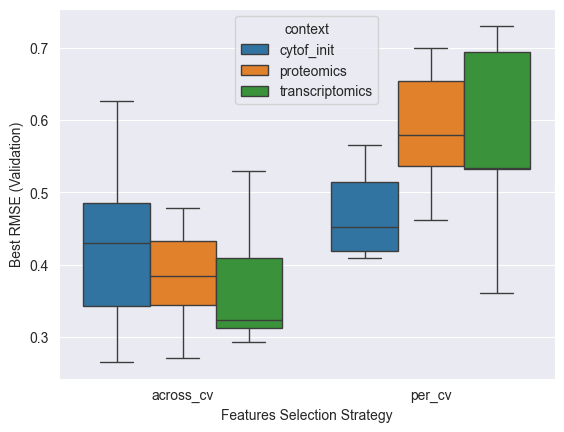

In [15]:
sns.boxplot(
    overall_summary,
    x="features_selection",
    y="mean_of_mins",
    hue="context",
    palette="tab10",
).set_ylabel("Best RMSE (Validation)")
plt.xlabel("Features Selection Strategy")

Text(0.5, 0, 'Features Selection Strategy')

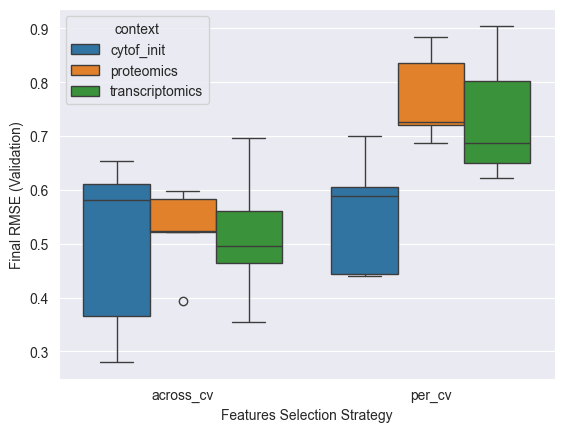

In [16]:
sns.boxplot(
    overall_summary,
    x="features_selection",
    y="mean_of_finals",
    hue="context",
    palette="tab10",
).set_ylabel("Final RMSE (Validation)")
plt.xlabel("Features Selection Strategy")

## Compare final RMSE (top10 training jobs) with baselines and regressors

In [17]:
top10_dmm = summary_top10[["context", "samples", "features_selection", "final_rmse_val"]].rename(
    columns={"final_rmse_val": "rmse"},
)
top10_dmm["mode"] = "dmm"
mean_top10dmm = top10_dmm.groupby(
    ["context", "samples", "features_selection", "mode"]
).agg(
    mean_rmse=("rmse", "mean"),
    std_rmse=("rmse", "std")
).reset_index()

mean_top10dmm.rename(
    columns={"mean_rmse": "rmse", "std_rmse": "rmse_std"},
    inplace=True
)

final_top10_df = pd.concat(
    [
        baseline_df[baseline_df.dataset == "val"][["context", "features_selection", "samples", "mode", "rmse"]], mean_top10dmm[["context", "samples", "features_selection", "mode", "rmse"]]
    ], ignore_index=True
)

<Figure size 1200x600 with 0 Axes>

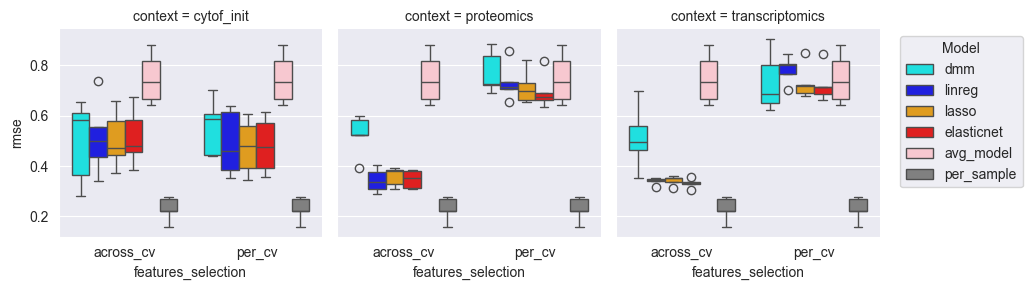

In [18]:
# Visualize the distribution of min mean rmse_val
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(
    final_top10_df,
    col="context",
    col_order=sorted(final_top10_df["context"].unique()),
)
g.map_dataframe(
    sns.boxplot,
    x="features_selection",
    y="rmse",
    hue="mode",
    hue_order=["dmm", "linreg", "lasso", "elasticnet", "avg_model", "per_sample"],
    palette={
        "dmm": "cyan",
        "linreg": "blue",
        "lasso": "orange",
        "elasticnet": "red",
        "avg_model": "pink",
        "per_sample": "gray"
    }
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Model")
